In [1]:
import json
from pathlib import Path
import numpy as np
from matplotlib import pyplot as plt


In [2]:
def get_metrics(stats, horizon=700):
    success = np.array([k['Success_Rate'] for k in stats])
    rzz = np.array([np.pad(np.array(k['Rzz_List'][:horizon]), (0,horizon - len(k['Rzz_List'][:horizon])), constant_values=0) for k in stats])[:,150:min(horizon,400)]
    
    succes_rate = np.mean(success)
    mean = rzz.mean(axis=1)

    trsh = np.cos(np.deg2rad(45))
    tt_trsh = np.where(np.argmax(rzz>trsh, axis=1) > 0, np.argmax(rzz>trsh, axis=1), rzz.shape[1])
    trsh_violation = 1 - np.sum(rzz>trsh, axis=1) / (min(horizon,400) - 150)

    return succes_rate, mean, tt_trsh, trsh_violation

### Testing different base policy stages 
catching metric such as success and constraint violations for the base case

[{'Return': 1.0, 'Horizon': 480, 'Success_Rate': 1.0, 'Rzz_List': [0.00047352436494679795, 0.0006298206193759981, 0.0006598095555256367, 0.0006656445808952971, 0.0006667790428636633, 0.000666998959869991, 0.0006670414879929587, 0.0006670496922151492, 0.0006670512714204713, 0.0006670515786337261, 0.0006670516337620724, 0.0006670516393082471, 0.0006670516490639433, 0.0006670516472061516, 0.0006670516490057121, 0.0006670516483465172, 0.0006670516472546129, 0.0006670516507807922, 0.0006670516476273702, 0.0006670516408949778, 0.0006670516500965618, 0.0006670516473742949, 0.0006670516449647779, 0.0006670516490783207, 0.0006670516472732091, 0.0006670516502723656, 0.0006670516480220545, 0.0006670516472701005, 0.0006670516507459867, 0.0006670516475784094, 0.000667051641953853, 0.0006670516495722034, 0.0006670516473064048, 0.0006670516484205136, 0.0006670516484865163, 0.000667051647260386, 0.0006670516507712443, 0.0006670516477702559, 0.0006670516417655037, 0.0006670516502553792, 0.0006670516474

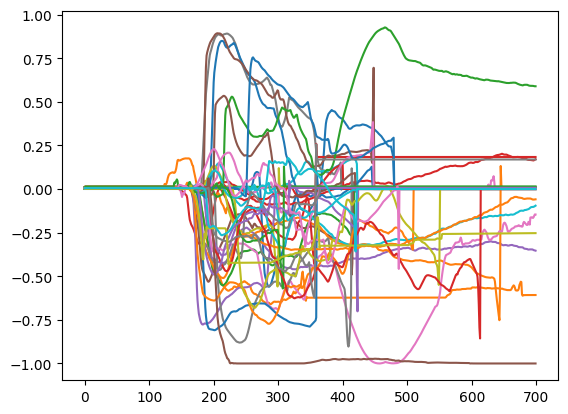

In [4]:
# Hardcoded stats file path (20:17 run)
stats_path = Path("../outputs/sr_rollout/base_models/20260206_201755/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

print(stats)
success = np.array([k['Success_Rate'] for k in stats])
rzz = np.array([np.pad(np.array(k['Rzz_List']), (0,700 - len(k['Rzz_List'])), constant_values=0) for k in stats])

print(np.average(rzz))
plt.plot(rzz.T)
plt.show()


In [6]:
succes_rate, mean_rzz, tt_trsh, trsh_violation = get_metrics(stats)
print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean_rzz)}\n'
      f'tt_trsh: {np.mean(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )

succes_rate: 0.425
mean_rzz: -0.12415557681460472
tt_trsh: 231.075
trsh_violation 0.9831


File: ../outputs/sr_rollout/base_models/model_epoch_2000/rollout_stats.json
succes_rate: 0.64
mean_rzz: -0.009632451703280408

File: ../outputs/sr_rollout/base_models/model_epoch_1850/rollout_stats.json
succes_rate: 0.42
mean_rzz: -0.017704836198662553

File: ../outputs/sr_rollout/base_models/20260206_201755/rollout_stats.json
succes_rate: 0.425
mean_rzz: -0.12415557681460472

File: ../outputs/sr_rollout/base_models/model_epoch_1300/rollout_stats.json
succes_rate: 0.38
mean_rzz: -0.07954980946738814

File: ../outputs/sr_rollout/base_models/model_epoch_1700/rollout_stats.json
succes_rate: 0.54
mean_rzz: -0.07506417731010498

File: ../outputs/sr_rollout/base_models/model_epoch_1500/rollout_stats.json
succes_rate: 0.42
mean_rzz: -0.036981874780861956



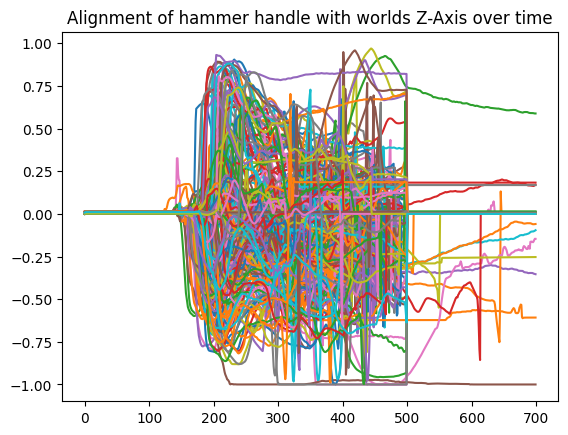

In [7]:
from pathlib import Path

root_dir = Path('../outputs/sr_rollout/base_models')
all_means = []


for subdir in root_dir.iterdir():
    # if subdir.name != 'model_epoch_2000': continue
    stats_file = subdir / 'rollout_stats.json'
    with Path.open(stats_file) as f:
        stats = json.load(f)
        print(f'File: {stats_file}') 
        succes_rate, mean_rzz, tt_trsh, trsh_violation = get_metrics(stats,horizon=500)
        all_means += list(mean_rzz)
        print(f'succes_rate: {succes_rate}\n'
            f'mean_rzz: {np.mean(mean_rzz)}\n'
            # f'tt_trsh: {np.mean(tt_trsh)}\n'
            # f'trsh_violation {np.mean(trsh_violation)}'
            )
        success = np.array([k['Success_Rate'] for k in stats])
        rzz = np.array([np.pad(np.array(k['Rzz_List']), (0,700 - len(k['Rzz_List'])), constant_values=0) for k in stats])

        plt.plot(rzz.T)
plt.title('Alignment of hammer handle with worlds Z-Axis over time')
plt.show()

-0.05487200188137618


<function matplotlib.pyplot.show(close=None, block=None)>

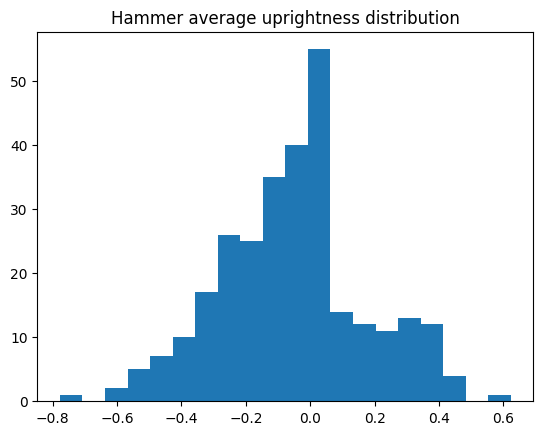

In [8]:
print(np.mean(all_means))
plt.hist(all_means, bins=20)
plt.title('Hammer average uprightness distribution')
plt.show

###  Sample and Rank to steer policy 
goal: max/min towards +1 or -1 uprightness score (didn't work as expected)

succes_rate: 0.56
mean_rzz: -0.18172178842609718
tt_trsh: 232.16
trsh_violation 0.9848


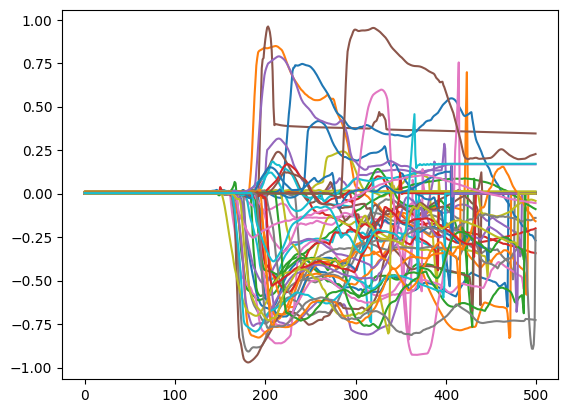

In [18]:

stats_path = Path("../outputs/sr_rollout/n16h500r50min/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

succes_rate, mean_rzz, tt_trsh, trsh_violation = get_metrics(stats, horizon=500)
print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean_rzz)}\n'
      f'tt_trsh: {np.mean(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )
success = np.array([k['Success_Rate'] for k in stats])
rzz = np.array([np.pad(np.array(k['Rzz_List']), (0,500 - len(k['Rzz_List'])), constant_values=0) for k in stats])
plt.plot(rzz.T)
plt.show()


### Sanity Check: How diverse is policy executing facing the SAME starting state?

[{'Return': 0.0, 'Horizon': 500, 'Success_Rate': 0.0, 'Rzz_List': [0.00923438525140835, 0.01222612286666308, 0.012593662723653198, 0.012637974922266204, 0.012643505222214635, 0.012644180024043938, 0.012644257269659454, 0.01264426505664673, 0.012644265623021567, 0.012644265613682593, 0.012644265597781978, 0.01264426559323606, 0.01264426559224946, 0.012644265592062276, 0.012644265592030801, 0.012644265592024972, 0.012644265592024029, 0.01264426559202303, 0.012644265592021975, 0.012644265592021475, 0.012644265592021198, 0.012644265592021253, 0.01264426559202142, 0.012644265592021475, 0.012644265592021309, 0.012644265592021309, 0.012644265592021309, 0.012644265592021475, 0.012644265592021198, 0.012644265592021475, 0.012644265592021475, 0.012644265592021309, 0.012644265592021475, 0.012644725872885731, 0.012660718732185494, 0.0126652933118937, 0.012664740364840166, 0.012668657436563924, 0.012670330569771626, 0.01267080435057727, 0.012672298743507504, 0.012672805858674807, 0.01266861598969404

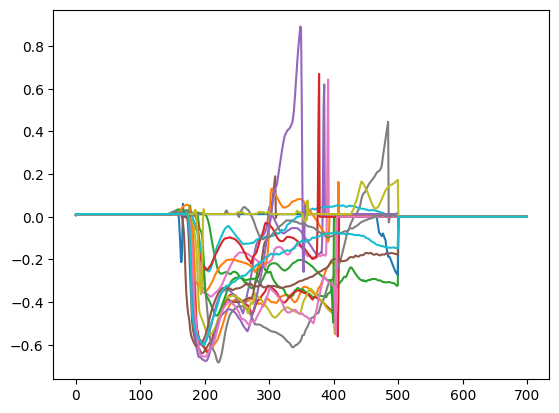

In [17]:

stats_path = Path("../outputs/sr_rollout/DP_fix_init_state_2/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

print(stats)
success = np.array([k['Success_Rate'] for k in stats])
rzz = np.array([np.pad(np.array(k['Rzz_List']), (0,700 - len(k['Rzz_List'])), constant_values=0) for k in stats])

succes_rate, mean_rzz, tt_trsh, trsh_violation = get_metrics(stats, horizon=500)
print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean_rzz)}\n'
      f'tt_trsh: {np.mean(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )
plt.plot(rzz.T)
plt.show()


[{'Return': 1.0, 'Horizon': 472, 'Success_Rate': 1.0, 'Rzz_List': [0.008922823052843643, 0.011797384428353763, 0.012150317340354377, 0.012192936592279713, 0.012198242506758439, 0.012198885724152009, 0.012198958351412159, 0.012198965444659426, 0.012198965898022884, 0.012198965870408474, 0.012198965851500265, 0.012198965846446974, 0.01219896584871999, 0.012198965845169718, 0.012198965844784027, 0.012198965844985754, 0.012198965845084564, 0.01219896584687663, 0.012198965845862109, 0.01219896584473501, 0.012198965844924803, 0.01219896584506136, 0.012198965838890186, 0.012198965847302234, 0.012198965844808174, 0.012198965844843757, 0.012198965845024168, 0.012198965845095056, 0.012198965847767418, 0.012198965845624299, 0.012198965844734788, 0.01219896584493585, 0.012198965845062693, 0.012198965838887521, 0.012198965847297849, 0.012198965844803622, 0.01219896584483926, 0.012198965845019727, 0.012198965845090337, 0.012198965848457866, 0.01219896584511565, 0.012205945300317989, 0.01221086367287

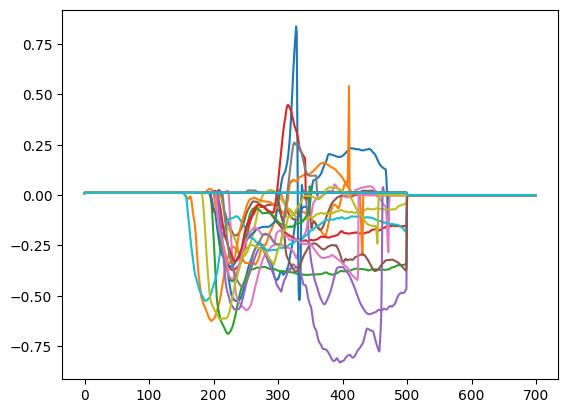

In [16]:

stats_path = Path("../outputs/sr_rollout/DP_fix_init_state_3/rollout_stats.json")
with stats_path.open() as f:
    stats = json.load(f)

print(stats)
success = np.array([k['Success_Rate'] for k in stats])
rzz = np.array([np.pad(np.array(k['Rzz_List']), (0,700 - len(k['Rzz_List'])), constant_values=0) for k in stats])

succes_rate, mean_rzz, tt_trsh, trsh_violation = get_metrics(stats, horizon=500)
print(f'succes_rate: {succes_rate}\n'
      f'mean_rzz: {np.mean(mean_rzz)}\n'
      f'tt_trsh: {np.mean(tt_trsh)}\n'
      f'trsh_violation {np.mean(trsh_violation)}'
      )
plt.plot(rzz.T)
plt.show()